In [4]:
# Classification Metrices explained From 
# https://medium.com/data-science/understanding-data-science-classification-metrics-in-scikit-learn-in-python-3bc336865019
# DataSet From : https://github.com/andrewwlong/classification_metrics_sklearn/blob/master/data.csv

In [5]:
import pandas as pd
df = pd.read_csv('data.csv')
df.head()

,actual_label,model_RF,model_LR
0,1,0.639816,0.531904
1,0,0.490993,0.414496
2,1,0.623815,0.569883
3,1,0.506616,0.443674
4,0,0.418302,0.369532


In [6]:
thresh = 0.5
df['predicted_RF'] = (df.model_RF >= 0.5).astype('int')
df['predicted_LR'] = (df.model_LR >= 0.5).astype('int')
df.head()

,actual_label,model_RF,model_LR,predicted_RF,predicted_LR
0,1,0.639816,0.531904,1,1
1,0,0.490993,0.414496,0,0
2,1,0.623815,0.569883,1,1
3,1,0.506616,0.443674,1,0
4,0,0.418302,0.369532,0,0


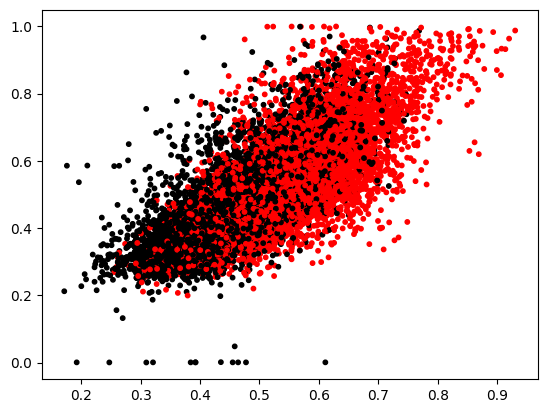

In [7]:
# My Own practice : Scatter Plot the dataset
import numpy as np
import matplotlib.pyplot as plt

colors = np.where(df['actual_label'], 'r', 'k')
plt.scatter(df.model_RF, df.model_LR, s=10, c=colors)

# Using Pandas plot

#df.plot.scatter('model_RF', 'model_LR', c=colors)

In [8]:
# Align futur markdown table to the let
%%html
<style>
table {float:left}
</style>

SyntaxError: invalid syntax (830867243.py, line 3)


## Lexique

En classication binaire (avec une classe d'intérêt) On a 2 labels binaires : 
- *actual_label* : le vrai, celui de la supervision
- *predicted_label* : celui prédit par le modèle considéré

On classe les échantillons en 4 catégories :
| Sign | Term        | Meaning                  |
---|-----------------|--------------------------
|TP| True Positive   | prédit 1  et  1 "en vrai"|
|FP| False Postitive | prédit 1 mais 0 "en vrai"|
|TN| True Negative   | prédit 0  et  0 "en vrai"|
|FN| False Negative  | predit 0 mais 1 "en vrai"|

![title](Précision_et_rappel.jpg)


### Résumé (mnémo-technique) :
- *Le premier terme qualifie la prédition bonne/mauvaise.* 
- *Le second terme est la valeur prédite (à tort ou à raison)*

Fasle Negative : Faussement prédit Négatif (Positif en vrai)



In [ ]:
# Matrice de confusion sur notr

In [12]:
# Matrice de confusion sur notre data set
# 
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(df.actual_label.values, df.predicted_RF.values)
cm

array([[5519, 2360],
       [2832, 5047]])

In [13]:
# So here we got
cm
# 5519 True Negatives
# 2360 False Positives
# 2832 False Negatives
# 5047 True Positives

array([[5519, 2360],
       [2832, 5047]])

In [15]:
# Confusion Matrix build 'by hand'
def find_TP(y_true, y_pred):
    # counts the number of true positives (y_true = 1, y_pred = 1)
    return sum((y_true == 1) & (y_pred == 1))
def find_FN(y_true, y_pred):
    # counts the number of false negatives (y_true = 1, y_pred = 0)
    return sum((y_true == 1) & (y_pred == 0))# your code here
def find_FP(y_true, y_pred):
    # counts the number of false positives (y_true = 0, y_pred = 1)
    return sum((y_true == 0) & (y_pred == 1))# your code here
def find_TN(y_true, y_pred):
    # counts the number of true negatives (y_true = 0, y_pred = 0)
    return sum((y_true == 0) & (y_pred == 0))# your code here

In [17]:
def find_conf_matrix_values(y_true,y_pred):
    # calculate TP, FN, FP, TN
    TP = find_TP(y_true,y_pred)
    FN = find_FN(y_true,y_pred)
    FP = find_FP(y_true,y_pred)
    TN = find_TN(y_true,y_pred)
    return TP,FN,FP,TN
def my_confusion_matrix(y_true, y_pred):
    TP,FN,FP,TN = find_conf_matrix_values(y_true,y_pred)
    return np.array([[TN,FP],[FN,TP]])


In [18]:
my_confusion_matrix(df.actual_label.values, df.predicted_RF.values)

array([[5519, 2360],
       [2832, 5047]])

In [20]:
assert  np.array_equal(my_confusion_matrix(df.actual_label.values, df.predicted_RF.values), confusion_matrix(df.actual_label.values, df.predicted_RF.values) ), 'my_confusion_matrix() is not correct for RF'
assert  np.array_equal(my_confusion_matrix(df.actual_label.values, df.predicted_LR.values),confusion_matrix(df.actual_label.values, df.predicted_LR.values) ), 'my_confusion_matrix() is not correct for LR'